<a href="https://colab.research.google.com/github/gokul171EK/AI_ML_Specific_Models/blob/main/DBSCAN%20Clustering%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving file_1.csv to file_1.csv
DATASET LOADED SUCCESSFULLY
Rows    : 300
Columns : 3


,x,y,target
0,-8.028029,-9.004721,2
1,-9.030661,-7.841498,2
2,-0.452835,5.962177,0
3,4.095676,4.720112,1
4,-11.974939,-9.400325,2



Cluster Distribution:
Cluster
 1    100
 0     99
 2     98
-1      3
Name: count, dtype: int64


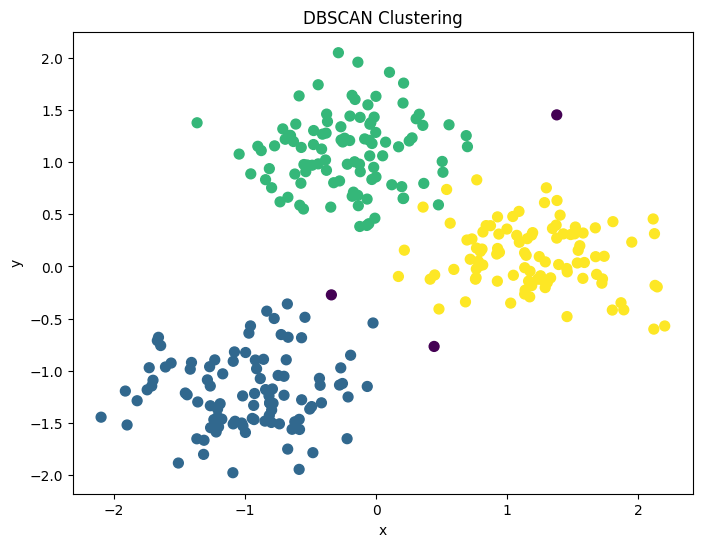


✅ DBSCAN COMPLETED
Output: dbscan_clustered_dataset.csv


In [1]:
# ============================================================
# DBSCAN CLUSTERING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Upload Dataset
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

display(df.head())

# Select Numerical Features
X = df.select_dtypes(include=np.number)

# Remove ID column if present
X = X.drop(columns=["StudentID"], errors="ignore")

# Handle Missing Values
X = X.fillna(X.mean())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

# Add Cluster Column
df["Cluster"] = clusters

# Display Cluster Distribution
print("\nCluster Distribution:")
print(df["Cluster"].value_counts())

# Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("DBSCAN Clustering")

plt.show()

# Save Result
df.to_csv(
    "dbscan_clustered_dataset.csv",
    index=False
)

print("\n" + "=" * 60)
print("✅ DBSCAN COMPLETED")
print("Output: dbscan_clustered_dataset.csv")
print("=" * 60)